### Варіант автоматизації щоденного звіту
* Це мій чорновий варіант автоматизації щоденного звіту. Файли які тут використовують створені як приклад штучним інтелектом і є лише приблизним прикладом.
* Сам ПДФ файл який ми генеруємо наприкінці є також приблизним і може удосконалюватись.
* Ми працюємо з папкою `test` яка знаходиться на моєму хмарному сховищі і в ній знаходиться папка `виписки`, де будуть лежати наші щодені виписки. Поки що робоча схема тут що хтось ці виписки генерує(звісно в подальшому це може бути не хмарне сховище, а база даних) і туди кладе(впевнена це теж можна автоматизувати). Я пропоную називати виписки за таким шаблоном `yyyy-MM-dd.csv`. Пізніше можна додати попередження що якщо в папці немає виписки за такий то день його необхідно туди додати щоб запустити цей скрипт.
* Щоб протестувати цей скрипт і запустити його самостійно, трохи нижче є зміна `report_date` - це єдине що я раджу тут змінювати. На диску ще є тестові 2025-08-02 і 2025-08-03, спробуйте їх замість 2025-08-01. Але спочатку звісно запустіть так як воно є.
* Як запустити? У верхньому правому кутку сторінки є іконка з вашим акаунтом гугл і щось накшталт Поділитися(Share), вам треба те що прямо під цим: Підключитись(Connect). Нажимаєте і почекайте доки відбудеться підключення.
* Вище є назва файлу і під ним є панель. Треба вибрати `Серидовище виконання` -> ` Виконати всі` (або назва може бути англійською, тобі треба `Environment`(або щось схоже) -> `Run all`). І ви побачите як кожна клітинка почне виконуватись одна за одною (бо це поступові дії), дайте час щоб усі клітинки виконались.
* Репорт має згенеруватись у папку `звіти`.
* Спробуйте змінити report_date та подивитесь як воно працює з іншими файлами (це до питання автоматизації, що воно усе буде запускатись автоматично і людина сама може собі генерувати ті репорти).
* Сподіваюсь усе відпрацює без помилок:)

In [45]:
# імпортуємо бібліотеки необхідні для роботи
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fpdf import FPDF
import os

In [46]:
# Підключаємо Google Drive - коли запитає треба обрати надати доступ і залогінитись під своїм акаунтом
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# Увага!!! для запуску тесту раджу спробувати змінити назву репорту(назва це наша дата)
# На диску ще є тестові 2025-08-02 і 2025-08-03, спробуйте їх замість 2025-08-01
report_date = "2025-08-01"

# Шлях до CSV на диску
file_path = f"/content/drive/MyDrive/test/виписки/{report_date}.csv"

# Завантаження і перегляд даних
df = pd.read_csv(file_path)
df.head()

,id,time,amount,source
0,1,03:35,99.06,банківський переказ
1,2,09:35,2325.03,криптовалюта
2,3,10:37,2223.04,банківський переказ
3,4,20:17,4946.60,банківський переказ
4,5,20:08,438.91,криптовалюта


In [50]:
# Конвертація часу в годину
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

# Метрики
total_amount = df['amount'].sum()
total_donations = df['id'].nunique()
top_source = df['source'].value_counts().idxmax()
mean_amount = df['amount'].mean()
max_amount = df['amount'].max()

print(f"Сума донатів: {total_amount:.2f} грн")
print(f"Кількість донатів: {total_donations}")
print(f"Найпопулярніше джерело: {top_source}")
print(f"Середній донат: {mean_amount:.2f} грн")
print(f"Максимальний донат: {max_amount:.2f} грн")


Сума донатів: 640313.30 грн
Кількість донатів: 600
Найпопулярніше джерело: банківський переказ
Середній донат: 1067.19 грн
Максимальний донат: 4992.14 грн


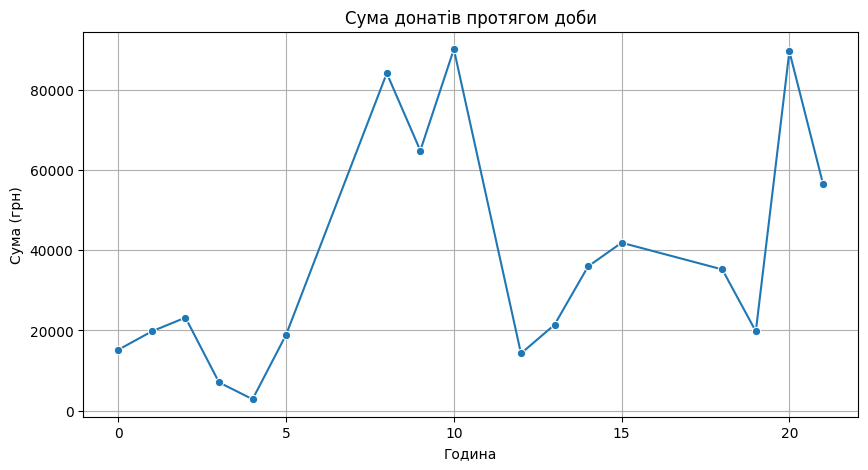

In [51]:
# Будуємо графік який покаже як змінюється сума донатів протягом доби
donation_by_hour = df.groupby('hour')['amount'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=donation_by_hour, x='hour', y='amount', marker='o')
plt.title('Сума донатів протягом доби')
plt.xlabel('Година')
plt.ylabel('Сума (грн)')
plt.grid(True)

# Збереження
plt.savefig('sum_by_hour.png')
plt.show()

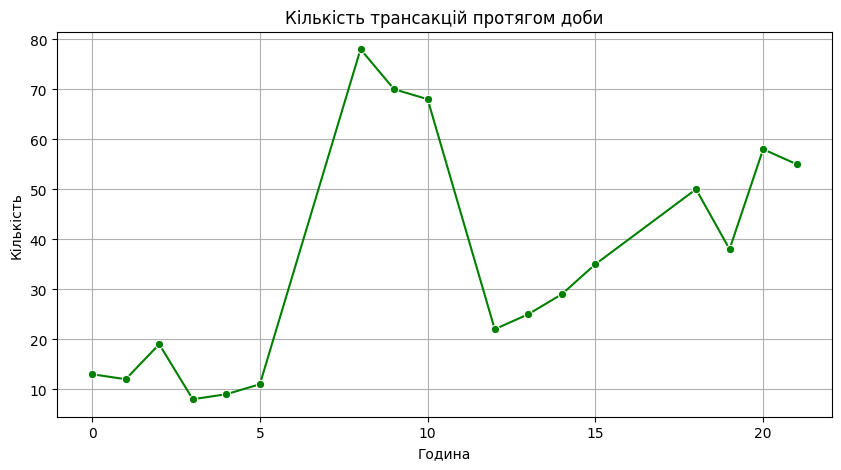

In [7]:
# Будуємо графік який покаже як змінюється кількість донатів протягом доби
count_by_hour = df.groupby('hour')['id'].count().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=count_by_hour, x='hour', y='id', marker='o', color='green')
plt.title('Кількість трансакцій протягом доби')
plt.xlabel('Година')
plt.ylabel('Кількість')
plt.grid(True)

plt.savefig('count_by_hour.png')
plt.show()


/tmp/ipython-input-1289154723.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_summary, x='source', y='amount', palette='Set2')


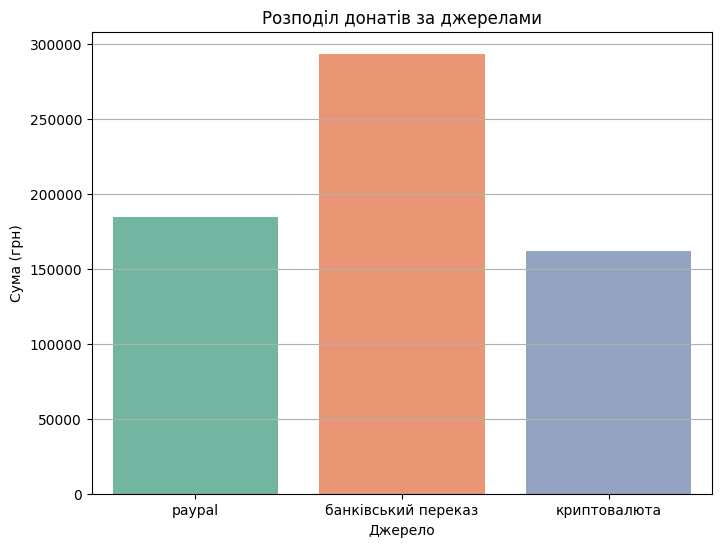

In [11]:
# Будуємо графік який покаже відношення суми донатів і звідки ті донати прийшли
source_summary = df.groupby('source')['amount'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=source_summary, x='source', y='amount', palette='Set2')
plt.title('Розподіл донатів за джерелами')
plt.xlabel('Джерело')
plt.ylabel('Сума (грн)')
plt.grid(axis='y')

plt.savefig('sum_by_source.png')
plt.show()


In [38]:
# це шлях до файлика на гугл диску, це файлик для шрифтів інакше ми не зможемо створити пдф з українськими шрифтами(кирилицею)
font_path = '/content/drive/MyDrive/test/DejaVuSans.ttf'

In [52]:
# Згенеруємо пдф файл з усією інформацією яку ми бачили вище
# Файл лежатиме у папці звіти

pdf = FPDF()
pdf.add_page()

# Додаємо підтримку шрифтів UTF-8 із локального файлу
pdf.add_font('DejaVu', '', font_path, uni=True)
pdf.add_font('DejaVu', 'B', font_path, uni=True)
pdf.set_font("DejaVu", size=12)

# Заголовок
pdf.set_font("DejaVu", 'B', 16)
pdf.cell(200, 10, txt="Звіт про донати за день", ln=True, align='C')
pdf.ln(10)

# Основна інформація
pdf.set_font("DejaVu", size=12)
pdf.cell(200, 10, txt=f"Дата звіту: {report_date}", ln=True)
pdf.cell(200, 10, txt=f"Загальна сума донатів: {total_amount:.2f} грн", ln=True)
pdf.cell(200, 10, txt=f"Кількість донатів: {total_donations}", ln=True)
pdf.cell(200, 10, txt=f"Середній донат: {mean_amount:.2f} грн", ln=True)
pdf.cell(200, 10, txt=f"Максимальний донат: {max_amount:.2f} грн", ln=True)
pdf.cell(200, 10, txt=f"Найпопулярніше джерело: {top_source}", ln=True)
pdf.ln(10)

# Шлях до зображень
images = [
    ("Сума донатів протягом доби", "sum_by_hour.png"),
    ("Кількість донатів протягом доби", "count_by_hour.png"),
    ("Сума донатів за джерелами", "sum_by_source.png")
]

# Додаємо зображення з підписами
for title, img_path in images:
    if os.path.exists(img_path):
        pdf.set_font("DejaVu", 'B', 12)
        pdf.cell(200, 10, txt=title, ln=True)
        pdf.image(img_path, x=10, w=190)
        pdf.ln(10)
    else:
        pdf.cell(200, 10, txt=f"[❌ Графік {img_path} не знайдено]", ln=True)

# Збереження PDF
pdf_filename = f"donation_report_{report_date}.pdf"
pdf_path = os.path.join("/content/drive/MyDrive/test/звіти", pdf_filename)
pdf.output(pdf_path)

print(f"✅ PDF-звіт збережено як '{pdf_filename}'")


✅ PDF-звіт збережено як 'donation_report_2025-08-01.pdf'
